In [2]:
#Following is the approach that I wanted to use but wasn't able to because it was taking too long to retrieve the data.
#I was getting the error - Timeout: Failed to perform, curl: (28) Connection timed out after 30014 milliseconds.

"""
pip install html-table-parser-python3
import urllib.request

from html_table_parser.parser import HTMLTableParser
import pandas as pd
def url_get_contents(url):
    req = urllib.request.Request(url=url)
    f = urllib.request.urlopen(req)
    return f.read()

html_contents = url_get_contents('https://www.screener.in/screens/357649/all-listed-companies/?page=2').decode('utf-8')
HTMLTableParser().feed(html_contents)
import time
names = []
for i in range(1,199):
  table = pd.read_html(f'https://www.screener.in/screens/357649/all-listed-companies/?page={i}')[0]
  names = names + table['Name'].tolist()
  time.sleep(2)
print(names)
pip install yahooquery
from yahooquery import search

tickers = {}
for name in names:
  result = search(name)
  if 'quotes' in result and result['quotes']:
    # Get the first result's symbol
    ticker = result['quotes'][0].get('symbol')
    tickers[name] = ticker
  else:
    tickers[name] = None

# Print results
for name, ticker in tickers.items():
    print(f"{name}: {ticker}")
import yfinance as yf


#Now we remove entries with None as ticker but this didn't work because half of them were removed
valid_tickers = [ticker for ticker in tickers.values() if ticker is not None]

#Download Adjusted Close data
data = yf.download(valid_tickers, start="2020-01-01", end="2025-01-01", auto_adjust=False, progress=True)

#Extract only the 'Adj Close' prices which we need for the Sharpe Ratio to choose the best stock
adj_close = data['Adj Close']

print(adj_close.head())
import numpy as np
#make empty dictionary to arrange each ticker with it's sharpe ratio, annual return and volatility
#same code as the last assignment
sharpe_data = {}

for ticker in adj_close.columns:
  #drop all missing data
    price_series = adj_close[ticker].dropna()

    #To handle missing values we'll drop stocks that have more than 2 yrs of missing data ie. less than 3yrs
    if len(price_series) >= 756:
        risk_free_rate = 0.044
        returns = price_series.pct_change().dropna()
        ann_return = returns.mean() * 252
        ann_vol = returns.std() * np.sqrt(252)
        sharpe = (ann_return - risk_free_rate) / ann_vol

        sharpe_data[ticker] = {
            'Annual Return': ann_return,
            'Annual Volatility': ann_vol,
            'Sharpe Ratio': sharpe
        }

#convert the dictionary to DataFrame
sharpe_df = pd.DataFrame.from_dict(sharpe_data, orient='index')

#sort the dataframe and get top 10 stocks
top_10 = sharpe_df.sort_values('Sharpe Ratio', ascending=False).head(10)
print(top_10)
"""

#This method would have to be repeated for other stock exchanges also. That would have taken even more time to run.

In [1]:
#So, I changed the  method to the following. I used online resources (Screener and Money Control) to choose 10 stocks of NSE,  BSE and NASDAQ each.
#I chose the top ten stocks that performed best in the past 5 years.
tickers = ['ADANIENT.NS', 'BEL.NS', 'TRENT.NS', 'TATAMOTORS.NS', 'M&M.NS', 'SHRIRAMFIN.NS', 'JSWSTEEL.NS', 'APOLLOHOSP.NS', 'TATASTEEL.NS', 'SBIN.NS', 'ADANIPORTS.BO', 'ICICIBANK.BO', 'BAJFINANCE.BO', 'LT.BO', 'BAJAJFINSV.BO', 'TITAN.BO', 'SUNPHARMA.BO',
           'NTPC.BO', 'BHARTIARTL.BO', 'POWERGRID.BO', 'NVDA', 'JPM', 'GS', 'DIS', 'AMZN', 'INTC', 'V', 'IBM', 'CAT', 'KO']

In [2]:
import yfinance as yf
import pandas as pd

#download data for last 5 years for all the chosen tickers to calculate returns
#set auto_adjust to false to get the adj close column
data = yf.download(tickers, start="2020-01-01", end="2025-01-01", progress=True, threads=True, auto_adjust=False)


[*********************100%***********************]  30 of 30 completed


In [3]:
data.head()

Price        Adj Close                                                       \
Ticker     ADANIENT.NS ADANIPORTS.BO       AMZN APOLLOHOSP.NS BAJAJFINSV.BO   
Date                                                                          
2020-01-01  205.827087    366.797455        NaN   1404.206055    925.968689   
2020-01-02  209.144485    372.430847  94.900497   1471.445923    938.457642   
2020-01-03  206.272690    371.702393  93.748497   1463.028442    922.547913   
2020-01-06  197.607864    369.274200  95.143997   1439.794922    893.478027   
2020-01-07  202.064072    373.596313  95.343002   1455.743408    897.683777   

Price                                                                      \
Ticker     BAJFINANCE.BO     BEL.NS BHARTIARTL.BO         CAT         DIS   
Date                                                                        
2020-01-01   4134.486328  29.909445    445.141205         NaN         NaN   
2020-01-02   4151.931152  30.805382    446.810638  133.744827  146.391510   
2020-01-03   4097.396973  30.148367    446.810638  131.887924  144.712280   
2020-01-06   3907.504639  28.953773    441.409607  131.799057  143.872635   
2020-01-07   3916.495605  28.774591    437.334290  130.057617  143.922028   

Price       ...       Volume                                         \
Ticker      ...         NVDA POWERGRID.BO     SBIN.NS SHRIRAMFIN.NS   
Date        ...                                                       
2020-01-01  ...          NaN    1331494.0  17379320.0     2196560.0   
2020-01-02  ...  237536000.0     295399.0  20324236.0     3168384.0   
2020-01-03  ...  205384000.0     783699.0  21853208.0     2353761.0   
2020-01-06  ...  262636000.0     374139.0  35645325.0     5609275.0   
2020-01-07  ...  314856000.0    1912603.0  50966826.0     2259925.0   

Price                                                                   \
Ticker     SUNPHARMA.BO TATAMOTORS.NS TATASTEEL.NS  TITAN.BO  TRENT.NS   
Date                                                                     
2020-01-01     351984.0    25968357.0  121005300.0  130373.0  107849.0   
2020-01-02     195055.0    57289863.0  216749610.0   95694.0  158640.0   
2020-01-03     338227.0    47572728.0  129568630.0   70128.0   63423.0   
2020-01-06     329710.0    28621212.0   96016080.0  172246.0  105970.0   
2020-01-07     456127.0    34995035.0  131957880.0  102829.0  153960.0   

Price                   
Ticker               V  
Date                    
2020-01-01         NaN  
2020-01-02   8733000.0  
2020-01-03   4899700.0  
2020-01-06  10109500.0  
2020-01-07   4392300.0  

[5 rows x 180 columns]

In [4]:
import numpy as np
#make a seperate df of the adj close prices to organize the following work,
adj_close = data['Adj Close']

#make a df of the daily log returns
returns = np.log(adj_close / adj_close.shift(1))

#the first row will be NAN so we will drop that
returns.dropna(inplace=True)
print(returns)

Ticker      ADANIENT.NS  ADANIPORTS.BO      AMZN  APOLLOHOSP.NS  \
Date                                                              
2020-01-03    -0.013826      -0.001958 -0.012213      -0.005737   
2020-01-06    -0.042914      -0.006554  0.014776      -0.016008   
2020-01-07     0.022300       0.011636  0.002089       0.011016   
2020-01-08    -0.012576       0.002596 -0.007839      -0.003421   
2020-01-09     0.031749       0.015566  0.004788       0.004030   
...                 ...            ...       ...            ...   
2024-12-24     0.014221      -0.008085  0.017573      -0.003461   
2024-12-26     0.011650       0.050578 -0.008770       0.002917   
2024-12-27     0.004033      -0.010628 -0.014641      -0.002047   
2024-12-30     0.072959      -0.009347 -0.011010       0.009334   
2024-12-31    -0.024879       0.007843 -0.008668      -0.002450   

Ticker      BAJAJFINSV.BO  BAJFINANCE.BO    BEL.NS  BHARTIARTL.BO       CAT  \
Date                                             

In [31]:
#compute correlation matrix of returns as instructed
correlation_matrix = returns.corr()

#display the correlation matrix
print(correlation_matrix)


Ticker         ADANIENT.NS  ADANIPORTS.BO      AMZN  APOLLOHOSP.NS  \
Ticker                                                               
ADANIENT.NS       1.000000       0.684532  0.012679       0.220496   
ADANIPORTS.BO     0.684532       1.000000  0.052637       0.234072   
AMZN              0.012679       0.052637  1.000000       0.033129   
APOLLOHOSP.NS     0.220496       0.234072  0.033129       1.000000   
BAJAJFINSV.BO     0.361565       0.413518  0.065730       0.370644   
BAJFINANCE.BO     0.364890       0.396899  0.065523       0.375401   
BEL.NS            0.324929       0.437411  0.035686       0.297760   
BHARTIARTL.BO     0.273300       0.347235  0.067388       0.234665   
CAT               0.091364       0.124036  0.245609       0.052480   
DIS               0.055208       0.096628  0.399397       0.065009   
GS                0.095249       0.158966  0.338415       0.131282   
IBM               0.120214       0.150444  0.253505       0.099906   
ICICIBANK.BO      0.

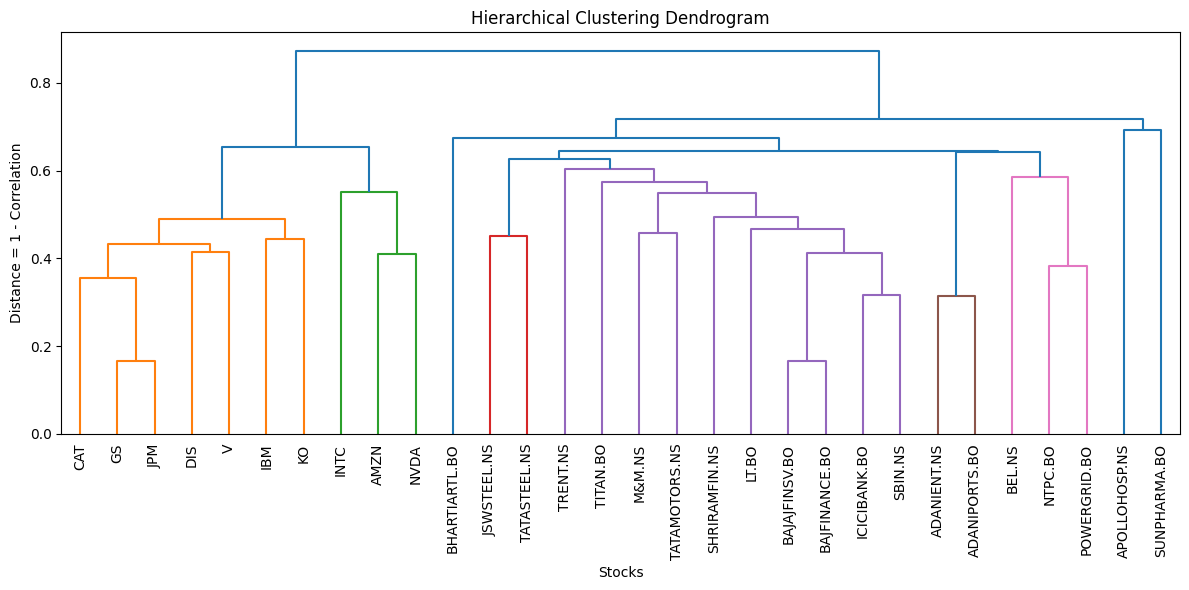

In [6]:
#moving on to making the dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns

#convert the correlation matrix to a distance matrix by using distance = 1 - correlation
distance_matrix = 1 - correlation_matrix

#convert square matrix to condensed format using squareform because that is required by linkage
condensed_dist = squareform(distance_matrix.values)

#forming the heirarchical clusters using linkage on the condesed_dist
Z = linkage(condensed_dist, method='average')

#Plotting the dendrogram as instructed
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=correlation_matrix.columns, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Stocks')
plt.ylabel('Distance = 1 - Correlation')
plt.tight_layout()
plt.show()


In [7]:
#From the two methods suggested (HRP and HERC) I am going to work on HERC because it builds on HRP and generally allocated better weights.
pip install riskfolio-lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.0/315.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.3/243.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 14.2 MB/s eta 0:00:00


In [10]:
#importing the library to directly do HERC
import riskfolio as rp

rolling_win = 126
recent_returns = returns.tail(rolling_win)

#now we initialize the hierarchical clustering portfolio (HCPortfolio) object which can be used for both HRP and HERC
port = rp.HCPortfolio(returns=recent_returns)

#using HERC
weights = port.optimization(
    model='HERC',               #using the HERC model
    codependence='pearson',     #going with linear codependence model = 'pearson'
    linkage='ward',             #using ward because it is generally preffered over the others accoring to a Medium article
    leaf_order=True             #sorting the dendrogram labels for clarity
)

#print the calculated weights
print(weights)


                weights
ADANIENT.NS    0.010150
ADANIPORTS.BO  0.017054
AMZN           0.036254
APOLLOHOSP.NS  0.027470
BAJAJFINSV.BO  0.021982
BAJFINANCE.BO  0.019512
BEL.NS         0.020156
BHARTIARTL.BO  0.036421
CAT            0.045368
DIS            0.041382
GS             0.044646
IBM            0.065426
ICICIBANK.BO   0.030102
INTC           0.024192
JPM            0.045440
JSWSTEEL.NS    0.023914
KO             0.107411
LT.BO          0.035137
M&M.NS         0.026248
NTPC.BO        0.033777
NVDA           0.016635
POWERGRID.BO   0.035830
SBIN.NS        0.026541
SHRIRAMFIN.NS  0.012570
SUNPHARMA.BO   0.048389
TATAMOTORS.NS  0.016890
TATASTEEL.NS   0.012179
TITAN.BO       0.037097
TRENT.NS       0.019860
V              0.061966


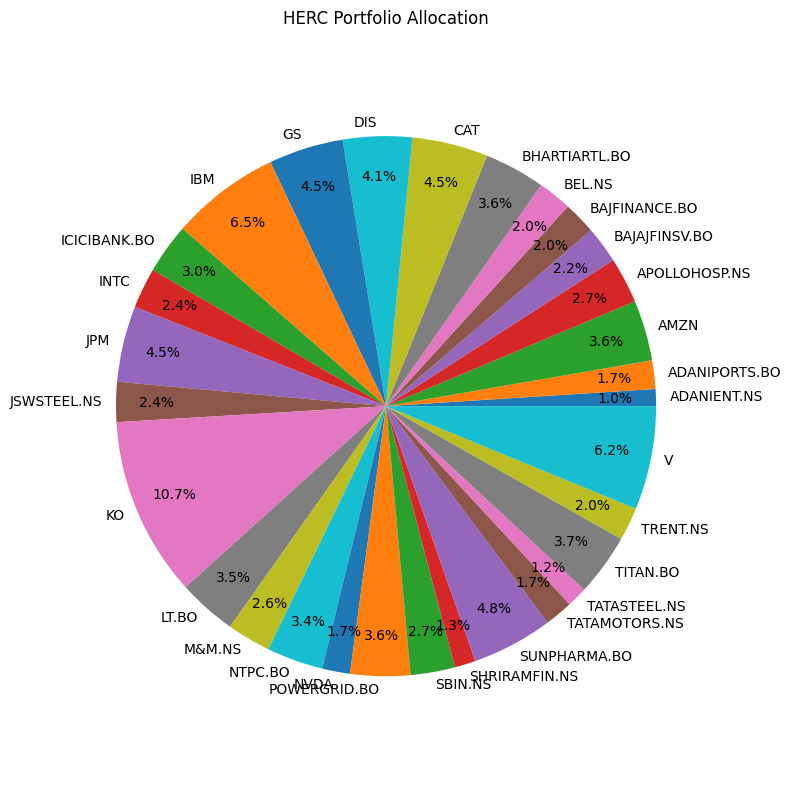

In [18]:
#now to visualize how well the weights have been divided I made a pie chart
import matplotlib.pyplot as plt

#from weights (which I am checking is a df because I got an error earlier) we take the first column
if isinstance(weights, pd.DataFrame):
    weights = weights.iloc[:, 0]



# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(weights.values, labels=weights.index,autopct='%1.1f%%', labeldistance = 1.05, pctdistance=0.85)
plt.title('HERC Portfolio Allocation')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [23]:
import pandas as pd
import numpy as np
import riskfolio as rp

#but what I have done till now doesn't rebalnce the weights or respond to change in correlation
#so we will change the code to implement dynamic allocation
lookback = 126                #set a lookback period
min_spacing = 21              #setting up a min gap to avoid too much reallocation
correlation_threshold = 0.05  #setting the threshhold to ~ 5%

#setting up a list to store
weight_history = []
last_mean_corr = None
last_rebalance_index = lookback
prev_weights = None

#now we'll use a for loop for rebalancing
for i in range(lookback, len(returns)):
    window_returns = returns.iloc[i - lookback:i]

    #compute the correlation matrix
    corr_matrix = window_returns.corr()
    upper_tri_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
    #and calculating the mean of all pairwise correlations using the upper triangle of the matrix
    mean_corr_now = np.mean(upper_tri_values)

    #now we set up a function to determine whether we should rebalance
    should_rebalance = (
        #last_mean_corr is None initially so we have to assign weights
        last_mean_corr is None or
        #if the change in correlation exceeds threshold then we would rebalance
        #provided the time passed is more than the min_spacing
        abs(mean_corr_now - last_mean_corr) > correlation_threshold
    ) and (i - last_rebalance_index >= min_spacing)

    #if the should_rebalance condition returns true then the following loop will run for rebalancing
    if should_rebalance:
        #initializing the Hierarchicial Cluster Portfolio which is used for both HRP and HERC
        port = rp.HCPortfolio(returns=window_returns)
        #I am calling the HERC model as decided
        #again we'll use linear codependence and ward
        weights = port.optimization(model='HERC', codependence='pearson', linkage='ward')
        #we need a series of weights so we'll ensure that they are convertied to series if they are a df
        weights = weights.iloc[:, 0] if isinstance(weights, pd.DataFrame) else weights
        weights = weights.reindex(window_returns.columns).fillna(0)

        #store the results in the lists created earlier
        weight_history.append((returns.index[i], weights))
        last_mean_corr = mean_corr_now
        last_rebalance_index = i

        prev_weights = weights


#now we'll convert the final values to a dataframe
weights_df = pd.DataFrame({date: w for date, w in weight_history}).T
weights_df.index.name = 'Date'


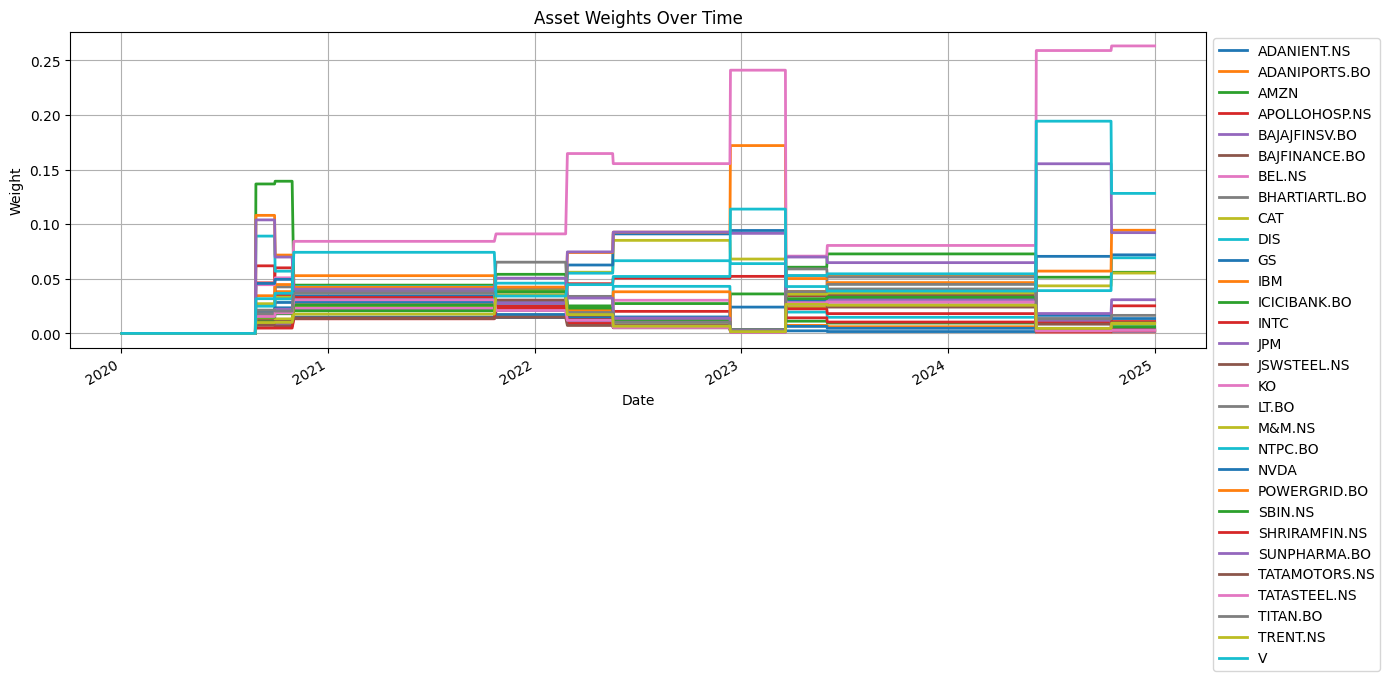

In [32]:
#plotting the weights alloted over time
weights_df.plot(figsize=(14, 6), lw=2)
plt.title("Asset Weights Over Time")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()


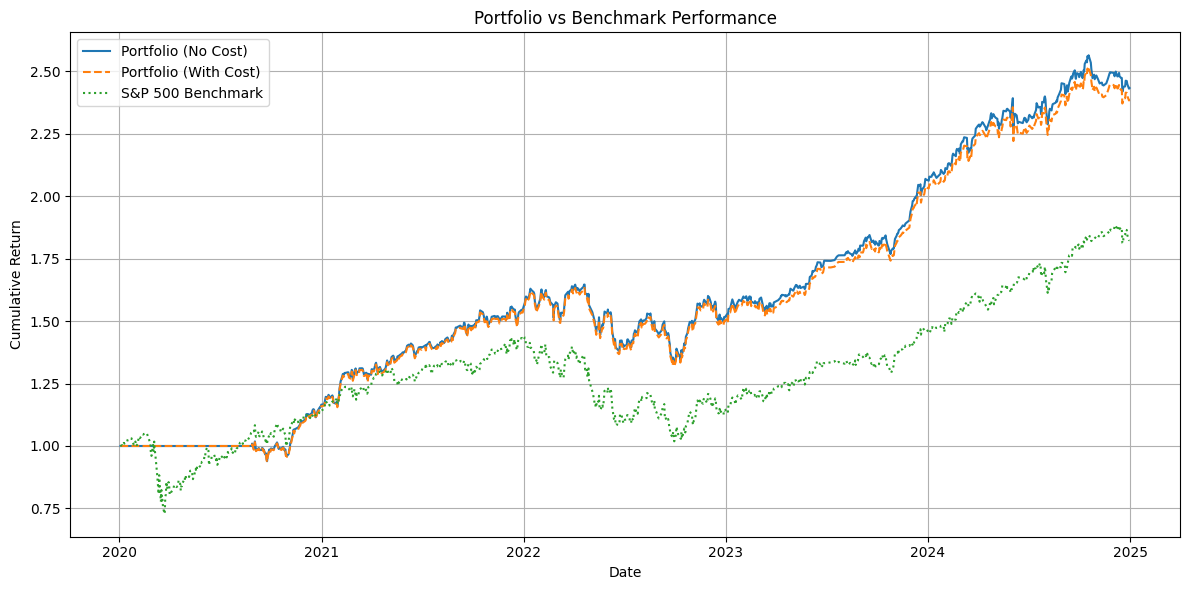

In [26]:
import yfinance as yf

#using S&P500 as the benchmark
sp500 = yf.download('^GSPC', start=returns.index.min(), end=returns.index.max(), progress=False, auto_adjust=False)

#Like out portfolio we use the adj close values and calculate returns
sp500['Returns'] = sp500['Adj Close'].pct_change()

#now to compare the 2 returns we align the benchmark returns to our portfolio return dates
benchmark_returns = sp500['Returns'].reindex(returns.index).fillna(0)

#now we calculate the cumulative returns of the benchmark
benchmark_cumulative = (1 + benchmark_returns).cumprod()

#we also ensure that the weights_df is aligned with returns
weights_df = weights_df.reindex(returns.index).ffill().fillna(0)

#for comparison we will take portfolio return without transaction cost
portfolio_returns_no_cost = (weights_df.shift(1) * returns).sum(axis=1)

#and we'll also compute transaction cost for a portcolio inclusing the cost
transaction_costs = []
prev_weights = None

for date in weights_df.index:
    current_weights = weights_df.loc[date]
    if prev_weights is not None:
        turnover = np.sum(np.abs(current_weights - prev_weights))
        cost = 0.003 * turnover
    else:
        cost = 0
    transaction_costs.append(cost)
    prev_weights = current_weights

transaction_costs_series = pd.Series(transaction_costs, index=weights_df.index)
portfolio_returns_with_cost = portfolio_returns_no_cost - transaction_costs_series

#we make two different return sets with and without costs
cumulative_no_cost = (1 + portfolio_returns_no_cost).cumprod()
cumulative_with_cost = (1 + portfolio_returns_with_cost).cumprod()


#as instructed we will now compare the two portfolios
plt.figure(figsize=(12, 6))
plt.plot(cumulative_no_cost, label='Portfolio (No Cost)')
plt.plot(cumulative_with_cost, label='Portfolio (With Cost)', linestyle='--')
plt.plot(benchmark_cumulative, label='S&P 500 Benchmark', linestyle=':')
plt.title('Portfolio vs Benchmark Performance')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
